In [102]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import networkx as nx
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [103]:
def build_gene_subgraph(matrix, gene_names, gene, top_targets=8):
    gene_names = list(gene_names)
    if gene not in gene_names:
        return None, 1.0

    idx = gene_names.index(gene)
    series = pd.Series(matrix[idx, :], index=gene_names).drop(gene, errors='ignore')
    top_idx = series.abs().nlargest(top_targets).index
    max_intensity = float(series.abs().max() or 1.0)

    G = nx.DiGraph()
    for tgt in top_idx:
        w = series[tgt]
        if w != 0:
            G.add_edge(gene, tgt, weight=float(w))
    return G, max_intensity


def draw_gene_subgraph(ax, G, gene, max_intensity):
    if G is None or G.number_of_edges() == 0:
        ax.text(0.5, 0.5, f"{gene}\n(no GRN data)", ha='center', va='center',
                transform=ax.transAxes, fontsize=6, color='gray')
        ax.axis('off')
        return

    # --- Layout : gène central fixé à (0, 0) ---
    fixed_positions = {gene: (0.0, 0.0)}
    pos = nx.spring_layout(
        G,
        pos=fixed_positions,
        fixed=[gene],
        k=2.5,
        iterations=100,
        seed=42
    )

    # --- Rayon minimum autour du centre ---
    min_radius = 0.6
    cx, cy = pos[gene]
    for node in pos:
        if node == gene:
            continue
        dx, dy = pos[node][0] - cx, pos[node][1] - cy
        dist = (dx**2 + dy**2) ** 0.5
        if dist < min_radius:
            scale = min_radius / (dist if dist > 1e-6 else 1e-6)
            pos[node] = (cx + dx * scale, cy + dy * scale)

    # --- Dessin ---
    node_colors = ['#4C9BE8' if n == gene else '#E8E8E8' for n in G.nodes]
    node_sizes  = [550 if n == gene else 380 for n in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=5.5, ax=ax)
    ax.margins(0.15)

    edges_pos = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    edges_neg = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] < 0]

    width_scale = 3.0
    wp = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_pos]
    wn = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_neg]

    kw_pos = dict(arrows=True, arrowsize=8, ax=ax, connectionstyle='arc3,rad=0.1')
    kw_neg = dict(
        ax=ax, connectionstyle='arc3,rad=0.1',
        arrows=True,
        arrowstyle='-[,widthB=0.8,lengthB=0.0',
        min_target_margin=12.5,
    )
    if edges_pos:
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u, v) for u, v, _ in edges_pos],
                               edge_color='#2ECC71', width=wp, **kw_pos)
    if edges_neg:
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u, v) for u, v, _ in edges_neg],
                               edge_color='#E74C3C', width=wn, **kw_neg)

    ax.set_title(f"Targets of {gene}", fontsize=6.5, fontweight='bold', pad=2)
    ax.axis('off')


# def draw_gene_subgraph(ax, G, gene, max_intensity):
#     if G is None or G.number_of_edges() == 0:
#         ax.text(0.5, 0.5, f"{gene}\n(no GRN data)", ha='center', va='center',
#                 transform=ax.transAxes, fontsize=6, color='gray')
#         ax.axis('off')
#         return

#     pos = nx.spring_layout(G, seed=42, pos={gene: (0.0, 0.0)}, fixed=[gene])
#     node_colors = ['#4C9BE8' if n == gene else '#E8E8E8' for n in G.nodes]
#     node_sizes  = [800 if n == gene else 600 for n in G.nodes]
#     nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
#     nx.draw_networkx_labels(G, pos, font_size=5.5, ax=ax)
#     ax.margins(0.15)

#     edges_pos = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] > 0]
#     edges_neg = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] < 0]
#     width_scale = 3.0 / max_intensity
#     kw = dict(ax=ax, connectionstyle='arc3,rad=0.1', min_target_margin=15)

#     if edges_pos:
#         nx.draw_networkx_edges(G, pos,
#                                edgelist=[(u, v) for u, v, _ in edges_pos],
#                                edge_color='#2ECC71',
#                                width=[abs(w) * width_scale for *_, w in edges_pos],
#                                arrows=True, arrowsize=8, **kw)
#     if edges_neg:
#         nx.draw_networkx_edges(G, pos,
#                                edgelist=[(u, v) for u, v, _ in edges_neg],
#                                edge_color='#E74C3C',
#                                width=[abs(w) * width_scale for *_, w in edges_neg],
#                                arrows=True,
#                                arrowstyle='-[,widthB=0.8,lengthB=0.0',
#                                **kw)

#     ax.set_title(f"Targets of {gene}", fontsize=6.5, fontweight='bold', pad=2)
#     ax.axis('off')


def draw_full_grn(ax, matrix, gene_names, top_k=50, min_edges_per_gene=2, top_incoming_per_target=5, ns=1):
    gene_names = list(gene_names)
    n = len(gene_names)
    gene_idx = {g: i for i, g in enumerate(gene_names)}

    all_abs = np.abs(matrix)
    max_w = all_abs.max() or 1.0

    G = nx.DiGraph()
    G.add_nodes_from(gene_names)

    off_diag = ~np.eye(n, dtype=bool)
    rows, cols = np.where(off_diag)
    abs_w = all_abs[rows, cols]

    if len(abs_w) == 0:
        ax.text(0.5, 0.5, 'No GRN edges available', ha='center', va='center',
                transform=ax.transAxes, fontsize=6, color='gray')
        ax.axis('off')
        return

    incoming_k = max(1, int(top_incoming_per_target))
    selected_edges = set()

    for tgt_idx, tgt_name in enumerate(gene_names):
        tgt_mask = cols == tgt_idx
        if not np.any(tgt_mask):
            continue

        tgt_rows = rows[tgt_mask]
        tgt_abs = abs_w[tgt_mask]
        k = min(incoming_k, len(tgt_abs))

        for edge_idx in np.argpartition(tgt_abs, -k)[-k:]:
            src_name = gene_names[tgt_rows[edge_idx]]
            selected_edges.add((src_name, tgt_name))

    if top_k is not None and int(top_k) > 0 and len(selected_edges) > int(top_k):
        sorted_edges = sorted(
            selected_edges,
            key=lambda e: abs(matrix[gene_idx[e[0]], gene_idx[e[1]]]),
            reverse=True,
        )
        selected_edges = set(sorted_edges[:int(top_k)])

    for src_name, tgt_name in selected_edges:
        G.add_edge(
            src_name,
            tgt_name,
            weight=float(matrix[gene_idx[src_name], gene_idx[tgt_name]]),
        )

    if G.number_of_edges() == 0:
        ax.text(0.5, 0.5, 'No GRN edges after filtering', ha='center', va='center',
                transform=ax.transAxes, fontsize=6, color='gray')
        ax.axis('off')
        return

    # Spring layout on undirected graph with edge weights
    G_und = G.to_undirected()
    for u, v in G_und.edges():
        ws = [abs(G[a][b]['weight']) for a, b in ((u, v), (v, u)) if G.has_edge(a, b)]
        G_und[u][v]['weight'] = float(np.mean(ws))
    pos = nx.spring_layout(G_und, weight='weight', seed=42,
                           k=6.0 / n**0.5, iterations=200)

    # All-pairs force pass: short-range repulsion + long-range attraction
    nodes_list = list(pos)
    if len(nodes_list) > 1:
        ideal_dist = 0.14
        repulsion_strength = 0.025
        attraction_strength = 0.010
        step_size = 0.15
        for _ in range(120):
            pos_arr = np.array([pos[nd] for nd in nodes_list])
            diff = pos_arr[:, None, :] - pos_arr[None, :, :]          # (N, N, 2)
            dist = np.linalg.norm(diff, axis=-1)                      # (N, N)

            pair_mask = ~np.eye(len(nodes_list), dtype=bool)
            safe_dist = np.where(pair_mask, dist, 1.0)

            unit = np.zeros_like(diff)
            nonzero = pair_mask & (safe_dist > 1e-9)
            unit[nonzero] = diff[nonzero] / safe_dist[nonzero][:, None]

            repel_mag = repulsion_strength * np.clip(ideal_dist - safe_dist, 0.0, None) / ideal_dist
            attract_mag = attraction_strength * np.clip(safe_dist - ideal_dist, 0.0, None) / ideal_dist
            net_mag = (repel_mag - attract_mag) * pair_mask

            delta = (unit * net_mag[:, :, None]).sum(axis=1)
            max_disp = np.linalg.norm(delta, axis=1).max()
            if max_disp < 1e-4:
                break

            for i, nd in enumerate(nodes_list):
                pos[nd] += step_size * delta[i]

    # Node appearance: colour by regulatory power
    reg_power = all_abs.sum(axis=1)
    node_power = np.array([reg_power[gene_idx[nd]] for nd in G.nodes]) / (reg_power.max() or 1.0)
    cmap = plt.cm.get_cmap('YlOrRd')
    nx.draw_networkx_nodes(G, pos, node_color=[cmap(p) for p in node_power],
                           node_size=100, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=3, ax=ax)
    ax.margins(0.12)

    # Edges
    edges_pos = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    edges_neg = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 0]
    widths = lambda el: [abs(G[u][v]['weight']) / max_w * 2.5 for u, v in el]
    kw = dict(arrows=True, arrowsize=7, connectionstyle='arc3,rad=0.12', min_target_margin=5, ax=ax)
    if edges_pos:
        nx.draw_networkx_edges(G, pos, edgelist=edges_pos,
                               edge_color='#2ECC71', width=widths(edges_pos), alpha=0.6, **kw)
    if edges_neg:
        nx.draw_networkx_edges(G, pos, edgelist=edges_neg,
                               edge_color='#E74C3C', width=widths(edges_neg), alpha=0.6, **kw)

    ax.legend(handles=[
        Line2D([0], [0], color='#2ECC71', linewidth=1.5, label='Activation'),
        Line2D([0], [0], color='#E74C3C', linewidth=1.5, label='Inhibition'),
    ], fontsize=5, loc='lower right', framealpha=0.7, borderpad=0.4)
    ax.set_title(f'GRN (Top {top_k} edges)',
                 fontsize=6.5, fontweight='bold', pad=2)
    ax.axis('off')

In [104]:
def load_grn_matrix(p, ns=1):
    """Charge la matrice GRN inférée (inter_simul.npy) et renvoie (matrix, gene_names)."""
    # data_full.h5ad si disponible, sinon data_train.h5ad
    full_path = os.path.join(p, 'Data', 'data_full.h5ad')
    train_path = os.path.join(p, 'Data', 'data_train.h5ad')
    adata = sc.read_h5ad(full_path if os.path.exists(full_path) else train_path)
    if ns == 1:
        genes = ['RA'] + list(adata.var_names)
    else:
        genes = ['Dox', 'Serum'] + list(adata.var_names)
    grn_path = os.path.join(p, 'cardamomOT', 'inter_simul.npy')
    grn_mat = np.load(grn_path)
    matrix = grn_mat[:, :, 0] if grn_mat.ndim == 3 else grn_mat
    return matrix, genes


def signed_log1p(x):
    """Transforme de façon symétrique: sign(x) * log1p(|x|)."""
    return np.sign(x) * np.log1p(np.abs(x))


def figure_sup1_3(
    datapath,
    figname='figure_sup1_3.pdf',
    top_k=100,
    min_edges_per_gene=2,
    min_label_gap=0.5,
    label_angle=12,
    ns=1,
):
    matrix, gene_names = load_grn_matrix(datapath, ns=ns)

    fig = plt.figure(figsize=(8.27, 11))
    gs   = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[2, 1],
                            hspace=0.15 , wspace=0.28)
    gs01 = gs[0, 0].subgridspec(2, 1, hspace=0.1, wspace=0.2)
    gs02 = gs[1, 0].subgridspec(2, 2, hspace=0.1, wspace=0.2)
    axes = (
    [fig.add_subplot(gs01[r, c]) for r in range(2) for c in range(1)] +
    [fig.add_subplot(gs02[r, c]) for r in range(2) for c in range(2)] )
    for ax, label, pos in zip(axes[:2], "AB", [-0.04, -0.35]):
        ax.text(pos, 1.05, label, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=8, fontweight="bold", clip_on=False)

    # Full GRN network in 1st plot of gs01
    draw_full_grn(axes[0], matrix, gene_names, top_k=top_k, min_edges_per_gene=min_edges_per_gene, ns=ns)

    # Heatmap of full GRN in 2nd plot of gs01 (signed log transform)
    matrix_heatmap = signed_log1p(matrix)
    extremum = np.max(np.abs(matrix_heatmap))
    im = axes[1].imshow(matrix_heatmap, aspect='equal', cmap='RdYlGn', vmin=-extremum, vmax=extremum)
    axes[1].set_box_aspect(1)
    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="4%", pad=0.05)
    fig.colorbar(im, cax=cax)

    # Violin plot of gene regulatory power to the right of the heatmap
    reg_power = np.log1p(np.abs(matrix[:, :] - np.diag(np.diag(matrix))).sum(axis=1))
    vax = divider.append_axes("right", size="50%", pad=0.80)
    vax.text(-0.35, 1.05, 'C', transform=vax.transAxes,
            ha="left", va="bottom", fontsize=8, fontweight="bold", clip_on=False)
    vax.violinplot(reg_power, showmeans=True, showextrema=False)

    # Overlay top 10 genes as points + labels
    top10_idx = np.argsort(reg_power)[::-1][:10]
    top10_power = reg_power[top10_idx]
    top10_genes = [gene_names[i] for i in top10_idx]
    x_top10 = np.ones(len(top10_power))
    vax.scatter(x_top10, top10_power, s=4, color='black', alpha=0.85, zorder=3)

    right_labeled_y = []
    left_labeled_y = []
    for y_val, gene in zip(top10_power, top10_genes):
        can_place_right = all(abs(y_val - prev_y) >= min_label_gap for prev_y in right_labeled_y)
        print(gene)
        if can_place_right or gene == 'Obox6':
            x_txt, ha, rot = 1.06, 'left', label_angle
            right_labeled_y.append(y_val)
        else:
            can_place_left = all(abs(y_val - prev_y) >= min_label_gap for prev_y in left_labeled_y)
            if not can_place_left:
                continue
            x_txt, ha, rot = 0.94, 'right', -label_angle
            left_labeled_y.append(y_val)

        vax.text(
            x_txt,
            y_val,
            gene,
            fontsize=5.5,
            va='center',
            ha=ha,
            rotation=rot,
            rotation_mode='anchor',
            clip_on=False,
        )

    vax.set_xticks([1])
    vax.set_xticklabels(['Sum of outgoing edges (logscale)'], fontsize=6)
    vax.tick_params(axis='y', labelsize=6)
    vax.set_title('Gene regulatory power', fontsize=6.5, fontweight='bold', pad=2)

    axes[1].set_title('GRN (signed log1p)')

    # Small GRNs for top 4 genes by regulatory power
    top4_idx = np.argsort(reg_power)[::-1][:4]
    top4_genes = [gene_names[i] for i in top4_idx]
    if 'Semrau' in datapath:
        top4_genes[3] = 'Dnmt3a'

    for ax, label in zip(axes[2:], "DEFG"):
        ax.text(-0.08, 1.05, label, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=8, fontweight="bold", clip_on=False)

    for ax, gene in zip(axes[2:], top4_genes):
        G, max_intensity = build_gene_subgraph(matrix, gene_names, gene)
        draw_gene_subgraph(ax, G, gene, max_intensity)

    plt.savefig(figname, dpi=600, bbox_inches='tight')
    plt.show()

/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_92237/1089502741.py:222: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


Hoxb2
RA
Lamb1
Esrrb
Dnmt3a
Col4a2
Klf2
Dppa2
Sox2
Klf4


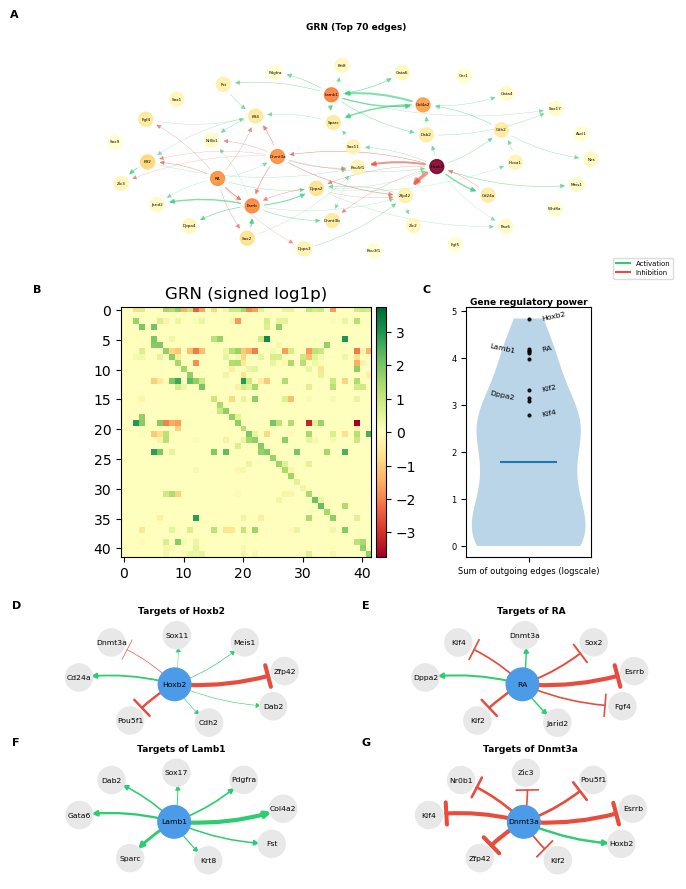

In [105]:
path_semrau = './../../experimental_datasets/Semrau'
figure_sup1_3(path_semrau, figname='figureS1.pdf', top_k=70, min_edges_per_gene=1)

/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_92237/1089502741.py:222: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


CHGA
RPL30
MEG3
HAND2
RA
ALDH1A1
POSTN
ATP5F1E
HAND2-AS1
HTATSF1


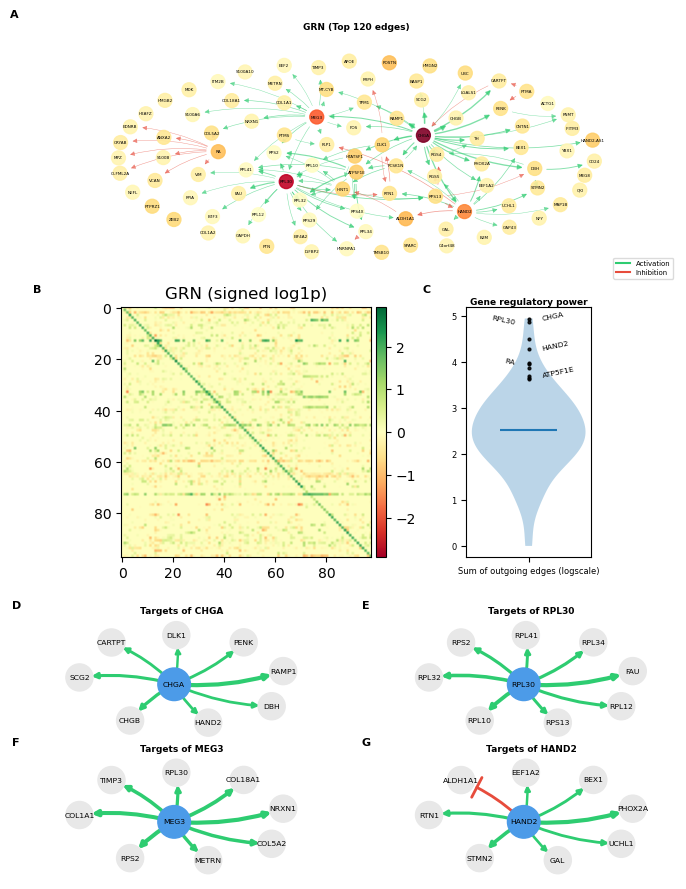

In [106]:
path_kameneva = './../../experimental_datasets/Kameneva'
figure_sup1_3(path_kameneva, figname='figureS2.pdf', top_k=120, min_edges_per_gene=0)

/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_92237/1089502741.py:222: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


Fabp3
Dox
Dppa5a
Serum
Ereg
Obox6
Txnip
Dmrtc2
Cdkn2a
S100a6


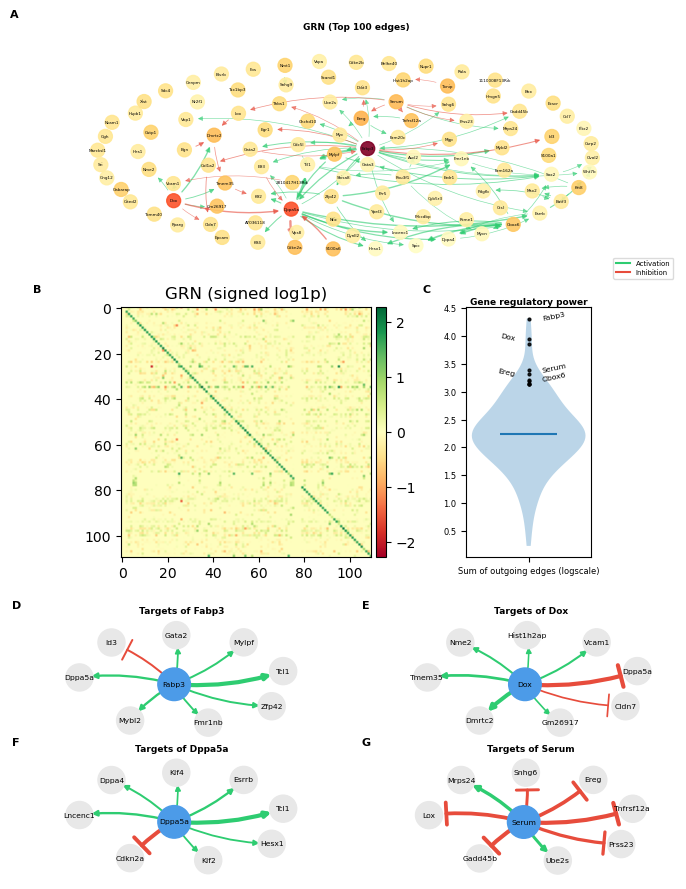

In [107]:
path_schiebinger = './../../experimental_datasets/Schiebinger'
figure_sup1_3(path_schiebinger, figname='figureS3.pdf', top_k=100, min_edges_per_gene=0, ns=2)